# Result Analysis

This notebook contains the analysis and visualization of voting prediction results.
Separated from the experiment running for better organization.

In [ ]:
# Core imports
import os
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import mean_absolute_error
from importlib import reload

# Local imports
from utils import sod_io, respondent_description, metrics, aggregation, visualization
from utils.constants import PARTY_COLUMNS_2021, GPT_41_NANO, GPT_4o_MINI, GPT_41, GPT_4o
from utils.voting import VotingProbabilities, VotingPick
from utils.client import generate_prob_vectors_df
from utils.io_results import results_to_dataframe

In [ ]:
# Configuration
LANGUAGE = sod_io.LANGUAGE_CZ
PARTIES = PARTY_COLUMNS_2021

# Load original data for claimed results comparison
data_path = sod_io.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)

# Vectorized extraction without Python loop
original_data = pd.read_csv("data/clean_data.csv", index_col=0)
print(f"Loaded survey data: {len(original_data)} respondents")

actual_results_df = metrics.load_actual_results()
actual_results_country = actual_results_df[actual_results_df["region"]=="Česko"].iloc[0]

In [ ]:
# Load voting results from saved files
# Modify the model name and file path as needed

# MODEL = GPT_41_NANO
# MODEL = GPT_4o_MINI
# MODEL = GPT_41
MODEL = GPT_4o

TEMPERATURE = 0

VOTING_RESULT = VotingProbabilities
# VOTING_RESULT = VotingPick

voting_results = pd.read_csv(f"results/voting_results_n=3880_t={TEMPERATURE}_{MODEL}_{VOTING_RESULT.__name__}.csv")
party_results_df = voting_results[PARTY_COLUMNS_2021].fillna(0)

In [ ]:
metrics.get_actual_results(original_data).to_csv(f"results/claimed_votes.csv")

In [73]:
# 1. Calculate row sums
row_sums = party_results_df.sum(axis=1)

# 2. Filter the DataFrame to keep only rows where sum is NOT 0
df_skipped = party_results_df[row_sums != 0].copy()

# 3. Normalize (Divide every value by the row sum)
party_results_df_norm_filtered = df_skipped.div(df_skipped.sum(axis=1), axis=0)

## Visualization

Generate comprehensive visualizations comparing predicted vs actual results.

In [ ]:
# Generate aggregated results and visualizations
predicted_results = aggregation.aggregate_results_from_df(voting_results)
fig = visualization.visualize_comprehensive_results(
    predicted_results,
    actual_results_country,
    PARTY_COLUMNS_2021,
    model_name=MODEL, actual_is_claimed=False
)

fig.savefig(f"graphs/{MODEL}_{VOTING_RESULT.__name__}.png")
print(f"Saved graph for {MODEL} and {VOTING_RESULT.__name__}")

In [ ]:
cov_matrix = party_results_df_norm_filtered[PARTY_COLUMNS_2021].cov()
fig = plt.figure(figsize=(10, 8))
sns.heatmap(
    cov_matrix,
    annot=True,       # CRITICAL: Show the numbers in the cells
    cmap='coolwarm',  # A diverging colormap is best to see pos/neg values
    fmt=".4f",        # Format to two decimal places
    linewidths=.5
)
plt.title(f'Covariance Matrix \n Model:{MODEL}', fontsize=18)
plt.show()

cov_matrix.to_csv(f"results/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.csv")
fig.savefig(f"graphs/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.png")
print(f"Saved covariance matrix and graph for {MODEL} and {VOTING_RESULT.__name__}")

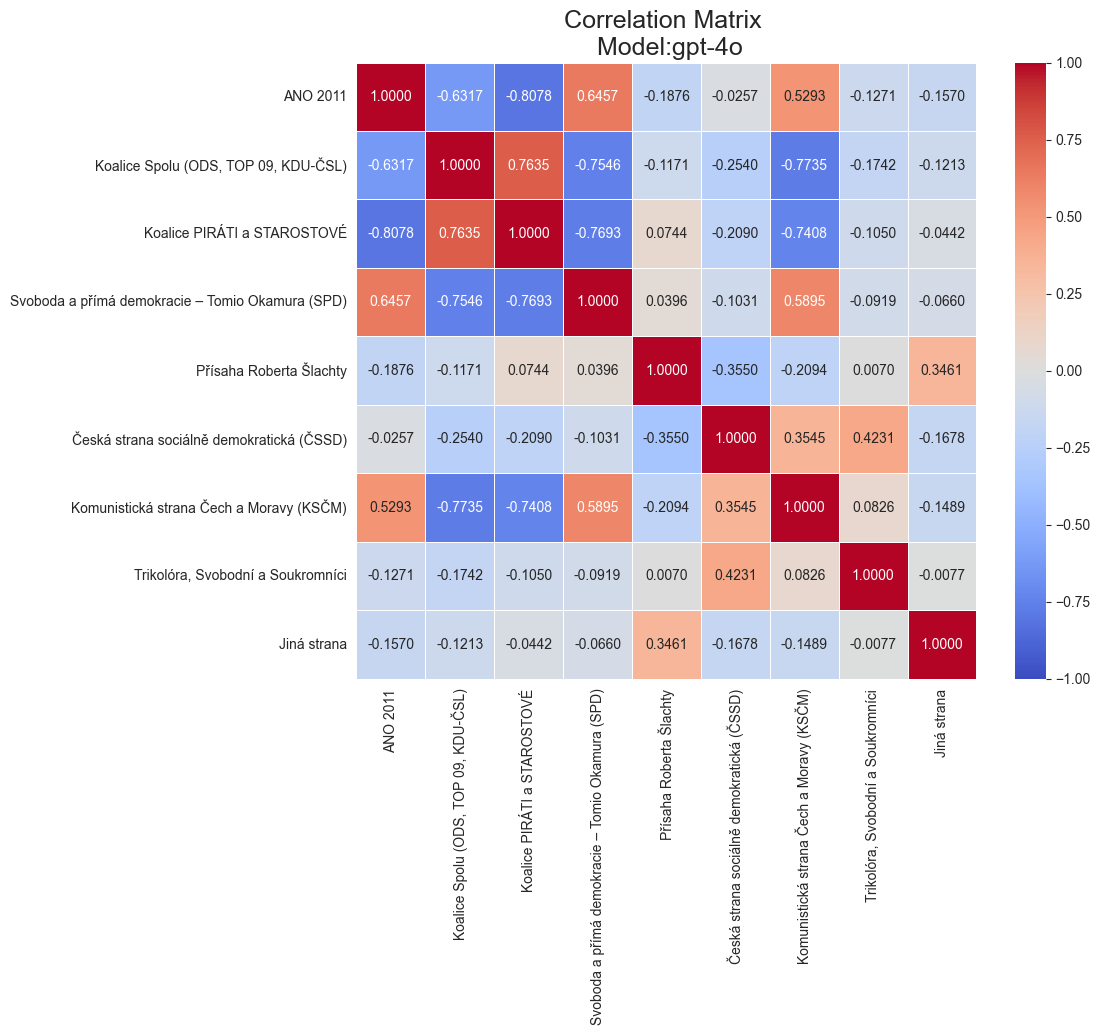

Saved correlation matrix and graph for gpt-4o and VotingProbabilities


In [80]:
# cov_matrix = pd.read_csv(f"results/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.csv",index_col=0)

std_devs = np.sqrt(np.diag(cov_matrix))
outer_std = np.outer(std_devs, std_devs)
corr_matrix = cov_matrix / outer_std
np.fill_diagonal(corr_matrix.values, 1.0)

fig = plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,       # CRITICAL: Show the numbers in the cells
    cmap='coolwarm',  # A diverging colormap is best to see pos/neg values
    fmt=".4f",        # Format to two decimal places
    linewidths=.5,
    vmin=-1.0, vmax=1.0
)
plt.title(f'Correlation Matrix \n Model:{MODEL}', fontsize=18)
plt.show()

fig.savefig(f"graphs/corr_matrix_{MODEL}_{VOTING_RESULT.__name__}.png")
print(f"Saved correlation matrix and graph for {MODEL} and {VOTING_RESULT.__name__}")

## Region Analysis

In [5]:
region_indices = original_data.groupby('region', observed=True).groups

In [ ]:
rows = []

for idx, actual_results_region in actual_results_df.iterrows():
    region = actual_results_region["region"]
    if region == 'Česko':
        claimed_votes_region = original_data
        predicted_votes_region = voting_results
    else:
        claimed_votes_region = original_data.iloc[region_indices[region]]
        predicted_votes_region = voting_results.iloc[region_indices[region]]

    claimed_results_region = metrics.get_actual_results(claimed_votes_region)
    predicted_results_region = aggregation.aggregate_results_from_df(predicted_votes_region)

    actual_results_region = actual_results_region[PARTY_COLUMNS_2021]
    predicted_results_region = predicted_results_region[PARTY_COLUMNS_2021]
    claimed_results_region = claimed_results_region[PARTY_COLUMNS_2021]

    mae_pred_vs_clmd = mean_absolute_error(predicted_results_region, claimed_results_region)
    mae_pred_vs_actu = mean_absolute_error(predicted_results_region, actual_results_region)
    mae_actu_vs_clmd = mean_absolute_error(actual_results_region, claimed_results_region)

    rows.append({
        "region": region,
        "Predicted vs Actual": round(mae_pred_vs_actu, 3),
        "Predicted vs Claimed": round(mae_pred_vs_clmd, 3),
        "Actual vs Claimed": round(mae_actu_vs_clmd, 3),
    })

regional_mae_df = pd.DataFrame(rows, columns=[
    "region",
    "Predicted vs Actual",
    "Predicted vs Claimed",
    "Actual vs Claimed",
])

# Ensure results directory exists
os.makedirs("results", exist_ok=True)
# Construct filename with model and temperature for traceability
csv_path = f"results/regional_pairwise_mae_t={TEMPERATURE}_{MODEL}.csv"
regional_mae_df.to_csv(csv_path, index=False)
print(f"Saved regional MAE CSV to: {csv_path}")

fig = visualization.visualize_region_errors(regional_mae_df, title=f"MAE Error Comparison by Region - Model: {MODEL}")
fig.savefig(f"graphs/regional_mae_{MODEL}.png")
regional_mae_df

## Result Distribution

In [ ]:
party_results_df_tmp = party_results_df
# party_results_df_tmp = generate_prob_vectors_df(4000, 9)

Calculated Mean Vector (Average Voter Profile):
[0.222 0.218 0.126 0.102 0.035 0.061 0.066 0.037 0.044]


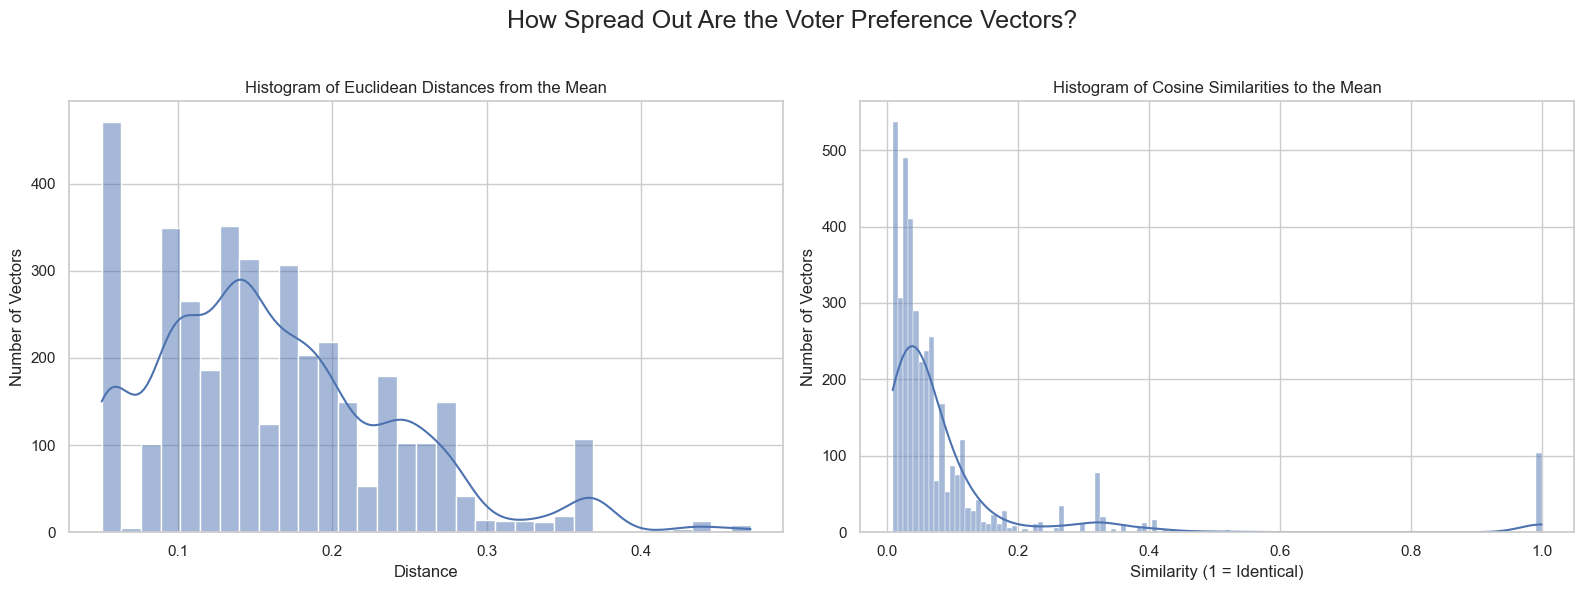

In [35]:
# --- Calculate the Mean Vector (The "Center of the Cloud") ---
mean_vector = party_results_df_tmp.mean().values
print("Calculated Mean Vector (Average Voter Profile):")
print(np.round(mean_vector, 3))

# --- Calculate Distances from Each Vector to the Mean ---
# We need to reshape the mean_vector for the distance functions
mean_vector_reshaped = mean_vector.reshape(1, -1)
euclidean_dists = euclidean_distances(party_results_df_tmp.values, mean_vector_reshaped).flatten()
cosine_sims = cosine_similarity(party_results_df_tmp.values, mean_vector_reshaped).flatten()

# --- Visualize the Spread with Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('How Spread Out Are the Voter Preference Vectors?', fontsize=18)

# Plot Euclidean Distance Histogram
sns.histplot(euclidean_dists, ax=axes[0], kde=True)
axes[0].set_title('Histogram of Euclidean Distances from the Mean')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Number of Vectors')

# Plot Cosine Similarity Histogram
sns.histplot(1-cosine_sims, ax=axes[1], kde=True)
axes[1].set_title('Histogram of Cosine Similarities to the Mean')
axes[1].set_xlabel('Similarity (1 = Identical)')
axes[1].set_ylabel('Number of Vectors')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
reload(visualization)
fig = visualization.visualize_party_probability_distribution(
    party_results_df_tmp,
    PARTY_COLUMNS_2021,
    title=f"Distribution of Party Probabilities – {MODEL}",
    kind="violin",
    add_points=False,
    point_size=2.0,
    alpha=0.25,
)
fig.savefig(f"graphs/party_probability_distribution_{MODEL}.png")
plt.show()

## Multi-Model Comparison

Compare results across different models.

In [5]:
# List of model names to compare
model_names = [
    "gpt-4.1-nano",
    "gpt-4o-mini",
    "gpt-4.1",
    "gpt-4o"
]

# Load all model results
voting_results_list = []
for model_name in model_names:
    try:
        voting_results_df = pd.read_csv(f"results/voting_results_n=3880_t={TEMPERATURE}_{model_name}_{VOTING_RESULT.__name__}.csv", index_col=0)
        voting_results_list.append(voting_results_df)
        print(f"✓ Loaded {model_name}: {len(voting_results_df)} respondents")
    except FileNotFoundError:
        print(f"✗ File not found for {model_name}")
        voting_results_list.append({})


✓ Loaded gpt-4.1-nano: 3880 respondents
✓ Loaded gpt-4o-mini: 3880 respondents
✓ Loaded gpt-4.1: 3880 respondents
✓ Loaded gpt-4o: 3880 respondents


In [ ]:
# Generate and save comparison graphs
for model_name, voting_results_df in zip(model_names, voting_results_list):

    predicted_results = aggregation.aggregate_results_from_df(voting_results_df)
    fig = visualization.visualize_comprehensive_results(
        predicted_results,
        actual_results_country,
        PARTY_COLUMNS_2021,
        model_name=model_name, actual_is_claimed=False
)
    # Save the plot as a PNG file
    if fig:
        fig.savefig(f"graphs/{model_name}.png")
        print(f"Saved graph for {model_name}")

In [ ]:
# Visualize the matrix with a heatmap
for model_name, voting_results_df in zip(model_names, voting_results_list):

    cov_matrix = voting_results_df[PARTY_COLUMNS_2021].cov()
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(
        cov_matrix,
        annot=True,       # CRITICAL: Show the numbers in the cells
        cmap='coolwarm',  # A diverging colormap is best to see pos/neg values
        fmt=".4f",        # Format to two decimal places
        linewidths=.5
    )
    plt.title(f'Covariance Matrix \n Model:{model_name}', fontsize=18)
    plt.show()

    cov_matrix.to_csv(f"results/cov_matrix_{model_name}.csv")
    fig.savefig(f"graphs/cov_matrix_{model_name}.png")
    print(f"Saved covariance matrix and graph for {model_name}")

## Latent

In [ ]:
latent_results_df = pd.read_csv(f"results/LatentPreferences.csv")
for idx,result in latent_results_df.iterrows():
    model = result['model']
    fig = visualization.visualize_comprehensive_results(
        result,
        actual_results_country,
        PARTY_COLUMNS_2021,
        model_name= model, actual_is_claimed=False
    )
    fig.savefig(f"graphs/latent_{model}.png")